In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
#Looad preprocessed data
output_dir = Path("Data/processed_outputs")

X_train      = joblib.load(output_dir / "X_train_supervised.pkl")
y_train      = joblib.load(output_dir / "y_train_supervised.pkl")
X_val        = joblib.load(output_dir / "X_val_supervised.pkl")
y_val        = joblib.load(output_dir / "y_val_supervised.pkl")
X_test       = joblib.load(output_dir / "X_test_supervised.pkl")
y_test       = joblib.load(output_dir / "y_test_supervised.pkl")
le           = joblib.load(output_dir / "label_encoder_supervised.pkl")
cw           = joblib.load(output_dir / "class_weights_supervised.pkl")
feature_names = joblib.load(output_dir / "feature_names.pkl")

print("Train shape:", X_train.shape)
print("Classes    :", list(le.classes_))

Train shape: (580313, 20)
Classes    : ['Bot', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTPTest', 'DoS-Slowloris', 'FTP-BruteForce', 'PortScan', 'SSH-BruteForce', 'Web-Attack']


In [3]:
#Build sample_weight vector
sample_weight = np.array([cw[label] for label in y_train])

In [4]:
model = XGBClassifier(
    objective        = "multi:softprob",
    num_class        = len(le.classes_),
    n_estimators     = 1000,        
    learning_rate    = 0.05,    
    max_depth        = 7,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    tree_method      = "hist",
    device           = "cpu",
    eval_metric      = ["mlogloss"],   
    early_stopping_rounds = 50,    
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 1,
)


In [5]:
model.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_val, y_val)],
    verbose       = 50,
)

print("Best iteration:", model.best_iteration)

[0]	validation_0-mlogloss:2.06958
[50]	validation_0-mlogloss:0.17891
[100]	validation_0-mlogloss:0.06254
[150]	validation_0-mlogloss:0.04793
[200]	validation_0-mlogloss:0.04407
[250]	validation_0-mlogloss:0.04245
[300]	validation_0-mlogloss:0.04174
[350]	validation_0-mlogloss:0.04137
[400]	validation_0-mlogloss:0.04121
[450]	validation_0-mlogloss:0.04112
[500]	validation_0-mlogloss:0.04103
[550]	validation_0-mlogloss:0.04097
[600]	validation_0-mlogloss:0.04097
[608]	validation_0-mlogloss:0.04098
Best iteration: 558


In [6]:
#Evaluate on validation set
y_val_pred = model.predict(X_val)

print("\n── Validation Report ──")
print(classification_report(
    y_val, y_val_pred,
    target_names = le.classes_,
    digits       = 4
))


── Validation Report ──
                  precision    recall  f1-score   support

             Bot     0.9997    1.0000    0.9998      3231
            DDoS     0.9940    0.9720    0.9829     44090
   DoS-GoldenEye     0.8615    0.9664    0.9110      7745
        DoS-Hulk     0.9984    0.9911    0.9947     30931
DoS-SlowHTTPTest     0.9936    0.9885    0.9910       784
   DoS-Slowloris     0.9976    0.9967    0.9971      2095
  FTP-BruteForce     0.9954    0.9985    0.9969       646
        PortScan     0.9999    0.9996    0.9997     13593
  SSH-BruteForce     1.0000    1.0000    1.0000     14097
      Web-Attack     0.6159    0.9863    0.7583       439

        accuracy                         0.9847    117651
       macro avg     0.9456    0.9899    0.9632    117651
    weighted avg     0.9866    0.9847    0.9853    117651



In [7]:
#Evaluate on held-out test set
y_test_pred = model.predict(X_test)

print("\n── Test Report ──")
print(classification_report(
    y_test, y_test_pred,
    target_names = le.classes_,
    digits       = 4
))


── Test Report ──
                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000      3232
            DDoS     0.9938    0.9737    0.9836     44090
   DoS-GoldenEye     0.8688    0.9645    0.9142      7745
        DoS-Hulk     0.9981    0.9915    0.9948     30931
DoS-SlowHTTPTest     0.9797    0.9847    0.9822       784
   DoS-Slowloris     0.9967    0.9976    0.9971      2094
  FTP-BruteForce     0.9938    0.9845    0.9891       647
        PortScan     0.9999    0.9990    0.9994     13592
  SSH-BruteForce     1.0000    0.9999    1.0000     14097
      Web-Attack     0.6291    0.9932    0.7703       439

        accuracy                         0.9852    117651
       macro avg     0.9460    0.9889    0.9631    117651
    weighted avg     0.9869    0.9852    0.9857    117651



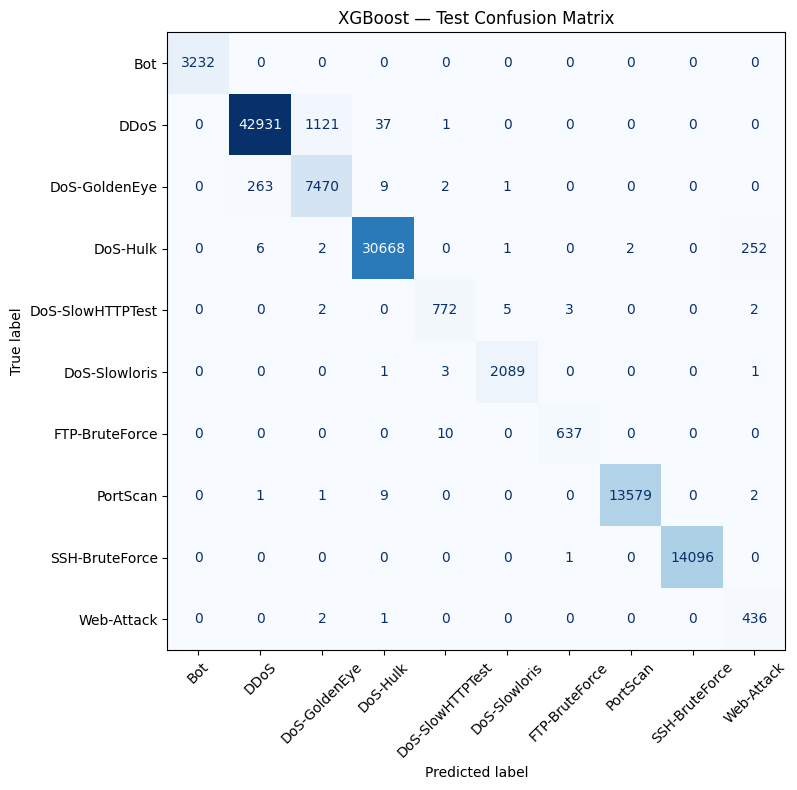

In [8]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Test Confusion Matrix")
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix_xgb.png", dpi=150)
plt.show()

In [9]:
importance = model.feature_importances_
fi_df = (
    __import__("pandas").DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .head(20)
)

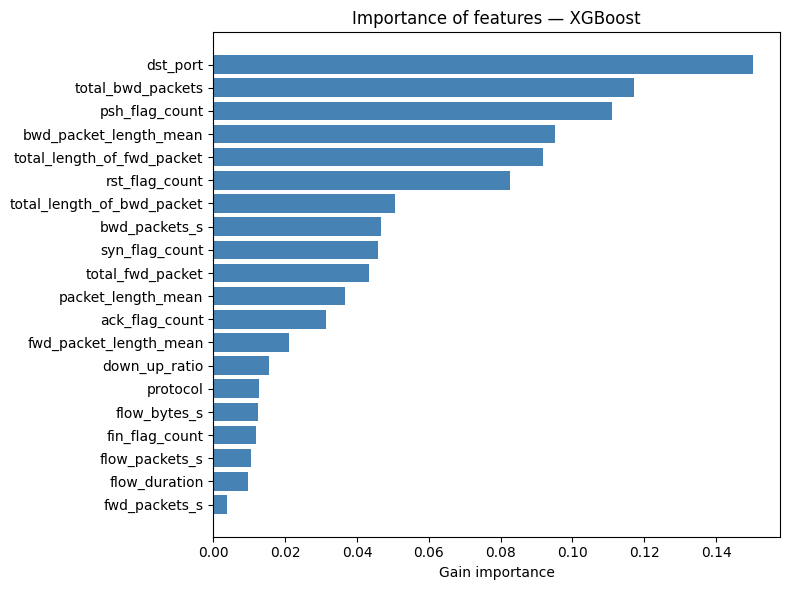

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Gain importance")
ax.set_title("Importance of features — XGBoost")
plt.tight_layout()
plt.savefig(output_dir / "feature_importance_xgb.png", dpi=150)
plt.show()

In [11]:
import pandas as pd

y_test_pred = model.predict(X_test)
le = joblib.load(output_dir / "label_encoder_supervised.pkl")

cm = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred),
    index=le.classes_,
    columns=le.classes_
)

# Show only the Web-Attack row and column
print("What Web-Attack gets predicted as:")
print(cm.loc["Web-Attack"])

print("\nWhat gets misclassified AS Web-Attack:")
print(cm["Web-Attack"])

What Web-Attack gets predicted as:
Bot                   0
DDoS                  0
DoS-GoldenEye         2
DoS-Hulk              1
DoS-SlowHTTPTest      0
DoS-Slowloris         0
FTP-BruteForce        0
PortScan              0
SSH-BruteForce        0
Web-Attack          436
Name: Web-Attack, dtype: int64

What gets misclassified AS Web-Attack:
Bot                   0
DDoS                  0
DoS-GoldenEye         0
DoS-Hulk            252
DoS-SlowHTTPTest      2
DoS-Slowloris         1
FTP-BruteForce        0
PortScan              2
SSH-BruteForce        0
Web-Attack          436
Name: Web-Attack, dtype: int64


In [12]:
#Web-Attack Confidence Threshold Tuning
y_proba = model.predict_proba(X_test)
web_attack_idx = list(le.classes_).index("Web-Attack")

for threshold in [0.8, 0.85, 0.88, 0.90, 0.92, 0.95]:
    y_pred_custom = np.argmax(y_proba, axis=1).copy()
    
    for i, probs in enumerate(y_proba):
        sorted_idx = np.argsort(probs)[::-1]
        if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < threshold:
            y_pred_custom[i] = sorted_idx[1]
    
    report = classification_report(
        y_test, y_pred_custom,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )
    wa = report["Web-Attack"]
    overall_acc = report["accuracy"]
    print(f"threshold={threshold:.2f} | precision={wa['precision']:.3f} | "
          f"recall={wa['recall']:.3f} | f1={wa['f1-score']:.3f} | "
          f"overall_acc={overall_acc:.4f}")

threshold=0.80 | precision=0.794 | recall=0.977 | f1=0.876 | overall_acc=0.9864
threshold=0.85 | precision=0.797 | recall=0.973 | f1=0.876 | overall_acc=0.9864
threshold=0.88 | precision=0.884 | recall=0.959 | f1=0.920 | overall_acc=0.9868
threshold=0.90 | precision=0.901 | recall=0.957 | f1=0.928 | overall_acc=0.9869
threshold=0.92 | precision=0.931 | recall=0.954 | f1=0.943 | overall_acc=0.9870
threshold=0.95 | precision=0.936 | recall=0.938 | f1=0.937 | overall_acc=0.9869


In [13]:
THRESHOLD = 0.95
web_attack_idx = list(le.classes_).index("Web-Attack")

y_proba = model.predict_proba(X_test)
y_pred_final = np.argmax(y_proba, axis=1).copy()

for i, probs in enumerate(y_proba):
    sorted_idx = np.argsort(probs)[::-1]
    if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < THRESHOLD:
        y_pred_final[i] = sorted_idx[1]

print(classification_report(
    y_test, y_pred_final,
    target_names=le.classes_,
    digits=4
))


                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000      3232
            DDoS     0.9938    0.9737    0.9836     44090
   DoS-GoldenEye     0.8687    0.9645    0.9141      7745
        DoS-Hulk     0.9975    0.9988    0.9982     30931
DoS-SlowHTTPTest     0.9797    0.9860    0.9828       784
   DoS-Slowloris     0.9962    0.9976    0.9969      2094
  FTP-BruteForce     0.9938    0.9845    0.9891       647
        PortScan     0.9998    0.9990    0.9994     13592
  SSH-BruteForce     0.9999    0.9999    0.9999     14097
      Web-Attack     0.9364    0.9385    0.9374       439

        accuracy                         0.9869    117651
       macro avg     0.9766    0.9843    0.9802    117651
    weighted avg     0.9878    0.9869    0.9872    117651



In [14]:
y_pred_val = model.predict(X_val)
val_proba  = model.predict_proba(X_val)

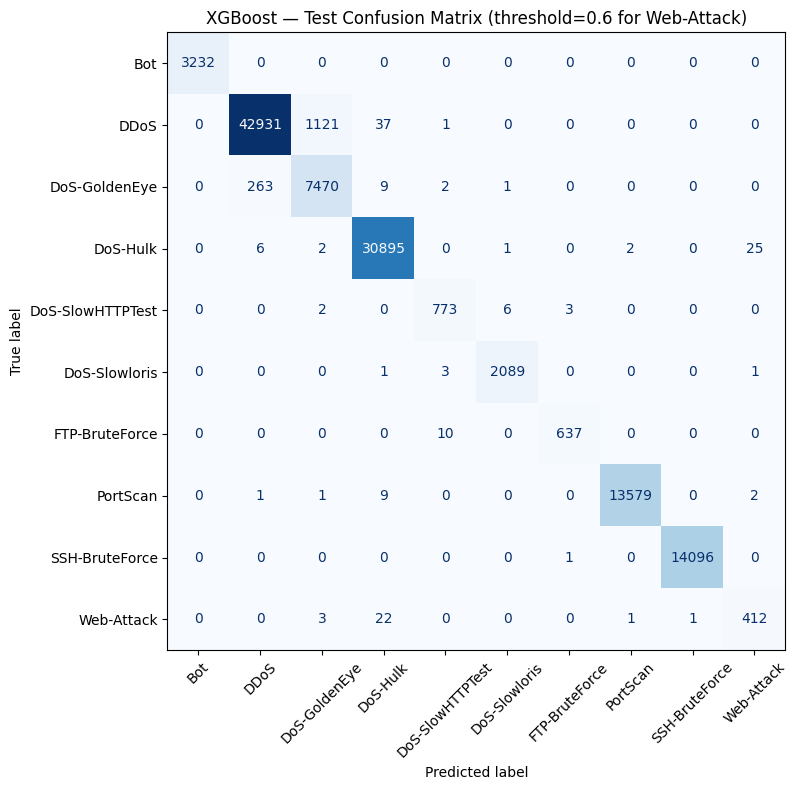

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Test Confusion Matrix (threshold=0.6 for Web-Attack)")
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix_xgb_final.png", dpi=150)
plt.show()

In [16]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd

y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

auc_scores = {}
for i, cls in enumerate(le.classes_):
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    auc_scores[cls] = round(auc, 4)

auc_df = pd.DataFrame.from_dict(auc_scores, orient="index", columns=["ROC-AUC"])
print(auc_df.sort_values("ROC-AUC", ascending=False))

                  ROC-AUC
Bot                1.0000
DoS-Hulk           1.0000
DoS-SlowHTTPTest   1.0000
DoS-Slowloris      1.0000
FTP-BruteForce     1.0000
PortScan           1.0000
SSH-BruteForce     1.0000
Web-Attack         0.9999
DDoS               0.9996
DoS-GoldenEye      0.9986


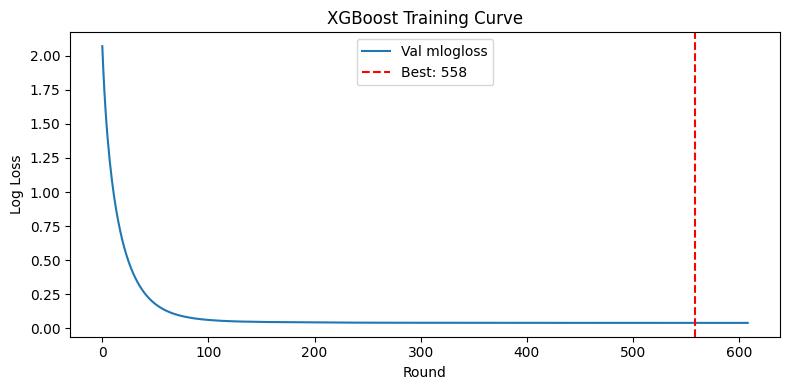

In [17]:
results = model.evals_result()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results["validation_0"]["mlogloss"], label="Val mlogloss")
ax.axvline(model.best_iteration, color="red", linestyle="--", 
           label=f"Best: {model.best_iteration}")
ax.set_xlabel("Round")
ax.set_ylabel("Log Loss")
ax.set_title("XGBoost Training Curve")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "training_curve_xgb.png", dpi=150)
plt.show()

In [18]:
import os

project_root = os.path.abspath(os.path.join(os.getcwd()))
models_path  = os.path.join(project_root, "Models")
os.makedirs(models_path, exist_ok=True)

# Predictions
joblib.dump(y_pred_val,   os.path.join(models_path, "xgb_preds_val.pkl"))
joblib.dump(y_pred_final, os.path.join(models_path, "xgb_preds_test.pkl"))

# Model
joblib.dump(model, os.path.join(models_path, "xgb_model.pkl"))
model.save_model(os.path.join(models_path, "xgb_model.json"))

# Probability scores
joblib.dump(val_proba, os.path.join(models_path, "xgb_val_scores.pkl"))
joblib.dump(y_proba,   os.path.join(models_path, "xgb_test_scores.pkl"))

# Threshold
joblib.dump(0.95, os.path.join(models_path, "xgb_web_attack_threshold.pkl"))

print("XGBoost artifacts saved to:", models_path)

XGBoost artifacts saved to: c:\AI_Cybersecurity\Models
